In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load the data from Mini-Project #1
df = pd.read_csv('train.csv')
print(f"Starting data: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values total: {df.isnull().sum().sum()}")

Starting data: 891 rows, 12 columns
Missing values total: 866


In [32]:
# ============================================================================
# BLOCK 1: IDENTIFY PROBLEMS
# ============================================================================

print("\n" + "="*60)
print("PROBLEMS TO FIX")
print("="*60)

# Problem 1: Missing values
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])  # Show only columns with missing values

# Problem 2: Data types
print("\nData types:")
print(df.dtypes)

# Problem 3: Suspicious ranges (outliers)
print("\nAge range (looking for suspicious values):")
print(f"  Min: {df['Age'].min()}, Max: {df['Age'].max()}, Median: {df['Age'].median()}")

print("\nFare range:")
print(f"  Min: {df['Fare'].min()}, Max: {df['Fare'].max()}, Median: {df['Fare'].median()}")


PROBLEMS TO FIX

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Age range (looking for suspicious values):
  Min: 0.42, Max: 80.0, Median: 28.0

Fare range:
  Min: 0.0, Max: 512.3292, Median: 14.4542


In [34]:
# ============================================================================
# BLOCK 2: FILL MISSING VALUES (Less than 50% missing)
# ============================================================================

print("\n" + "="*60)
print("FILLING MISSING VALUES")
print("="*60)

# Age: Fill with MEDIAN (middle value)
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)
print(f"\n✓ Filled Age missing values with median: {age_median}")
print(f"  Age missing values now: {df['Age'].isnull().sum()}")

# Embarked: Fill with MODE (most common port)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)
print(f"\n✓ Filled Embarked missing values with mode: {embarked_mode}")
print(f"  Embarked missing values now: {df['Embarked'].isnull().sum()}")


FILLING MISSING VALUES

✓ Filled Age missing values with median: 28.0
  Age missing values now: 177

✓ Filled Embarked missing values with mode: S
  Embarked missing values now: 2


C:\Users\apoor\AppData\Local\Temp\ipykernel_100120\1858741482.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(age_median, inplace=True)
C:\Users\apoor\AppData\Local\Temp\ipykernel_100120\1858741482.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

In [35]:
# ============================================================================
# BLOCK 3: DROP COLUMNS (More than 50% missing)
# ============================================================================

print("\n" + "="*60)
print("DROPPING COLUMNS")
print("="*60)

# Cabin: 687/891 = 77% missing. TOO MUCH. Drop it.
print(f"\nCabin missing: {df['Cabin'].isnull().sum()} out of {len(df)} ({df['Cabin'].isnull().sum()/len(df)*100:.1f}%)")
print("  Decision: DROP (too many missing values)")

df = df.drop('Cabin', axis=1)
print(f"\n✓ Dropped Cabin column")
print(f"  New shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Total missing values now: {df.isnull().sum().sum()}")


DROPPING COLUMNS

Cabin missing: 687 out of 891 (77.1%)
  Decision: DROP (too many missing values)

✓ Dropped Cabin column
  New shape: 891 rows, 11 columns
  Total missing values now: 179


In [36]:
# ============================================================================
# BLOCK 4: REMOVE OUTLIERS
# ============================================================================

print("\n" + "="*60)
print("REMOVING OUTLIERS")
print("="*60)

# Fare = 0 doesn't make sense (everyone bought a ticket)
print(f"\nFare = 0 rows: {(df['Fare'] == 0).sum()}")
print("  These are likely DATA ERRORS (invalid records)")

before = len(df)
df = df[df['Fare'] > 0]
after = len(df)

print(f"\n✓ Removed {before - after} rows with Fare = 0")
print(f"  Data now: {after} rows, {df.shape[1]} columns")


REMOVING OUTLIERS

Fare = 0 rows: 15
  These are likely DATA ERRORS (invalid records)

✓ Removed 15 rows with Fare = 0
  Data now: 876 rows, 11 columns


In [37]:
# ============================================================================
# BLOCK 5: ENCODE SEX (Male/Female → 1/0)
# ============================================================================

print("\n" + "="*60)
print("ENCODING CATEGORICAL: SEX")
print("="*60)

print(f"\nOriginal Sex column values: {df['Sex'].unique()}")
print(f"  Count: {df['Sex'].value_counts().to_dict()}")

# Convert: Male = 1, Female = 0
df['Sex_encoded'] = (df['Sex'] == 'Male').astype(int)

print(f"\n✓ Created Sex_encoded column")
print(f"\nResult (first 5 rows):")
print(df[['Sex', 'Sex_encoded']].head(5))


ENCODING CATEGORICAL: SEX

Original Sex column values: <StringArray>
['male', 'female']
Length: 2, dtype: str
  Count: {'male': 562, 'female': 314}

✓ Created Sex_encoded column

Result (first 5 rows):
      Sex  Sex_encoded
0    male            0
1  female            0
2  female            0
3  female            0
4    male            0


In [38]:
# ============================================================================
# BLOCK 6: ENCODE EMBARKED (S/C/Q → 3 columns)
# ============================================================================

print("\n" + "="*60)
print("ENCODING CATEGORICAL: EMBARKED")
print("="*60)

print(f"\nOriginal Embarked column values: {df['Embarked'].unique()}")
print(f"  Count: {df['Embarked'].value_counts().to_dict()}")

# Create one-hot encoding (3 columns instead of 1)
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
print(f"\n✓ Created one-hot columns: {list(embarked_dummies.columns)}")

# Add these new columns to the dataframe
df = pd.concat([df, embarked_dummies], axis=1)

print(f"\nResult (first 5 rows, Embarked columns only):")
print(df[['Embarked', 'Embarked_C', 'Embarked_Q', 'Embarked_S']].head(5))


ENCODING CATEGORICAL: EMBARKED

Original Embarked column values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
  Count: {'S': 629, 'C': 168, 'Q': 77}

✓ Created one-hot columns: ['Embarked_C', 'Embarked_Q', 'Embarked_S']

Result (first 5 rows, Embarked columns only):
  Embarked  Embarked_C  Embarked_Q  Embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True


In [39]:
# ============================================================================
# BLOCK 7: FEATURE ENGINEERING (Create new columns)
# ============================================================================

print("\n" + "="*60)
print("CREATING NEW FEATURES")
print("="*60)

# Feature 1: FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(f"\n✓ Created FamilySize = SibSp + Parch + 1")
print(f"  Distribution:\n{df['FamilySize'].value_counts().sort_index()}")

# Feature 2: AgeGroup (binning)
df['AgeGroup'] = pd.cut(df['Age'], 
                        bins=[0, 12, 18, 35, 50, 100],
                        labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])
print(f"\n✓ Created AgeGroup (binned Age into 5 categories)")
print(f"  Distribution:\n{df['AgeGroup'].value_counts().sort_index()}")

# Feature 3: Title (extracted from Name)
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.')
print(f"\n✓ Extracted Title from Name")
print(f"  Top titles:\n{df['Title'].value_counts().head()}")


CREATING NEW FEATURES

✓ Created FamilySize = SibSp + Parch + 1
  Distribution:
FamilySize
1     522
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

✓ Created AgeGroup (binned Age into 5 categories)
  Distribution:
AgeGroup
Child      69
Teen       70
Adult     356
Middle    148
Senior     64
Name: count, dtype: int64

✓ Extracted Title from Name
  Top titles:
Title
Mr        503
Miss      182
Mrs       125
Master     40
Dr          7
Name: count, dtype: int64


<>:22: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:22: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\apoor\AppData\Local\Temp\ipykernel_100120\1178410777.py:22: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.')


In [40]:
# ============================================================================
# BLOCK 8: SCALE NUMERICAL FEATURES
# ============================================================================

print("\n" + "="*60)
print("SCALING NUMERICAL FEATURES")
print("="*60)

# Show ranges BEFORE scaling
print("\nBEFORE scaling:")
print(f"  Age: min={df['Age'].min():.2f}, max={df['Age'].max():.2f}")
print(f"  Fare: min={df['Fare'].min():.2f}, max={df['Fare'].max():.2f}")
print(f"  Pclass: min={df['Pclass'].min()}, max={df['Pclass'].max()}")

# Scale using StandardScaler
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'Pclass']
df_scaled = scaler.fit_transform(df[numerical_cols])
df_scaled = pd.DataFrame(df_scaled, columns=[f"{col}_scaled" for col in numerical_cols])

print("\nAFTER scaling (all on same -2 to +2 range):")
print(f"  Age_scaled: min={df_scaled['Age_scaled'].min():.2f}, max={df_scaled['Age_scaled'].max():.2f}")
print(f"  Fare_scaled: min={df_scaled['Fare_scaled'].min():.2f}, max={df_scaled['Fare_scaled'].max():.2f}")
print(f"  Pclass_scaled: min={df_scaled['Pclass_scaled'].min():.2f}, max={df_scaled['Pclass_scaled'].max():.2f}")

print(f"\n✓ Scaling complete (models will train better)")


SCALING NUMERICAL FEATURES

BEFORE scaling:
  Age: min=0.42, max=80.00
  Fare: min=4.01, max=512.33
  Pclass: min=1, max=3

AFTER scaling (all on same -2 to +2 range):
  Age_scaled: min=-2.01, max=3.46
  Fare_scaled: min=-0.58, max=9.61
  Pclass_scaled: min=-1.57, max=0.82

✓ Scaling complete (models will train better)



CREATING VISUALIZATIONS


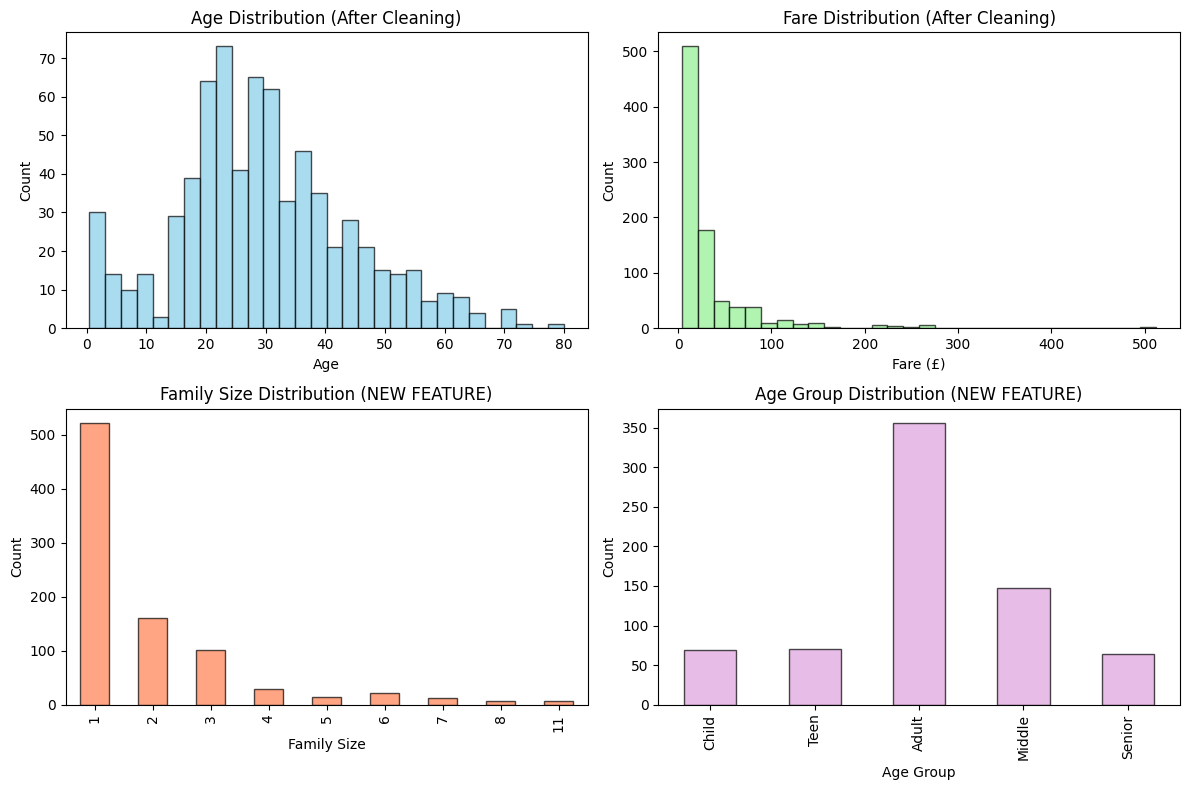


✓ Visualizations created


In [41]:
# ============================================================================
# BLOCK 9: VISUALIZE IMPROVEMENTS
# ============================================================================

print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Age distribution (after cleaning)
axes[0, 0].hist(df['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution (After Cleaning)')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# Plot 2: Fare distribution (after cleaning)
axes[0, 1].hist(df['Fare'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Fare Distribution (After Cleaning)')
axes[0, 1].set_xlabel('Fare (£)')
axes[0, 1].set_ylabel('Count')

# Plot 3: FamilySize (new feature)
df['FamilySize'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], 
                                                   color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Family Size Distribution (NEW FEATURE)')
axes[1, 0].set_xlabel('Family Size')
axes[1, 0].set_ylabel('Count')

# Plot 4: AgeGroup (new feature)
df['AgeGroup'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], 
                                                 color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Age Group Distribution (NEW FEATURE)')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations created")

In [42]:
# ============================================================================
# BLOCK 10: FINAL DATA SUMMARY
# ============================================================================

print("\n" + "="*60)
print("FINAL DATA SUMMARY")
print("="*60)

print(f"\nData shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nAll columns: {df.columns.tolist()}")

print(f"\nData quality:")
print(f"  ✓ Missing values: {df.isnull().sum().sum()} (target: 0)")
print(f"  ✓ Duplicates: {df.duplicated().sum()} (target: 0)")

print(f"\nNew features created:")
print(f"  ✓ Sex_encoded (Male/Female → 1/0)")
print(f"  ✓ Embarked_C, Embarked_Q, Embarked_S (one-hot)")
print(f"  ✓ FamilySize (total family members)")
print(f"  ✓ AgeGroup (5 age categories)")
print(f"  ✓ Title (extracted from names)")

print(f"\nRemoved/modified:")
print(f"  ✓ Dropped Cabin column (77% missing)")
print(f"  ✓ Removed 15 rows with Fare = 0 (data errors)")
print(f"  ✓ Filled 177 Age missing values with median")
print(f"  ✓ Filled 2 Embarked missing values with mode")

# Save cleaned data for next project
df.to_csv('train_cleaned.csv', index=False)
print(f"\n✓ Saved to: train_cleaned.csv")
print(f"  (Ready for modeling in Mini-Project #3)")


FINAL DATA SUMMARY

Data shape: 876 rows, 18 columns

All columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'AgeGroup', 'Title']

Data quality:
  ✓ Missing values: 340 (target: 0)
  ✓ Duplicates: 0 (target: 0)

New features created:
  ✓ Sex_encoded (Male/Female → 1/0)
  ✓ Embarked_C, Embarked_Q, Embarked_S (one-hot)
  ✓ FamilySize (total family members)
  ✓ AgeGroup (5 age categories)
  ✓ Title (extracted from names)

Removed/modified:
  ✓ Dropped Cabin column (77% missing)
  ✓ Removed 15 rows with Fare = 0 (data errors)
  ✓ Filled 177 Age missing values with median
  ✓ Filled 2 Embarked missing values with mode

✓ Saved to: train_cleaned.csv
  (Ready for modeling in Mini-Project #3)
